In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("data/hour.csv")

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [3]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

In [6]:
df.dtypes

instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [7]:
(df["casual"])+df["registered"]==df["cnt"].all()

0        False
1        False
2        False
3        False
4         True
         ...  
17374    False
17375    False
17376    False
17377    False
17378    False
Length: 17379, dtype: bool

In [8]:
df["instant"].nunique()

17379

In [9]:
len(df)

17379

In [10]:
(df["casual"] + df["registered"] == df["cnt"]).all()

np.True_

In [11]:
df.drop(columns=["instant","casual","registered"],inplace=True)

In [12]:
df.columns

Index(['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='str')

In [13]:
df["dteday"].head()

0    2011-01-01
1    2011-01-01
2    2011-01-01
3    2011-01-01
4    2011-01-01
Name: dteday, dtype: str

In [14]:
df["dteday"].dtype

<StringDtype(na_value=nan)>

In [15]:
df.drop("dteday",axis=1,inplace=True)

In [16]:
df.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='str')

In [17]:
X=df.drop("cnt",axis=1)
y=df["cnt"]

In [18]:
print(X.shape)
print(y.shape)

(17379, 12)
(17379,)


In [19]:
X.dtypes

season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
dtype: object

In [20]:
categorical_columns=[
    "season","yr","mnth","hr","holiday","weekday","workingday","weathersit"
]

numerical_columns=[
    "temp","atemp","hum","windspeed"
]


In [21]:
print(categorical_columns)
print()

print(numerical_columns)

['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']

['temp', 'atemp', 'hum', 'windspeed']


In [22]:
df[["yr", "mnth", "hr"]].head()

,yr,mnth,hr
0,0,1,0
1,0,1,1
2,0,1,2
3,0,1,3
4,0,1,4


In [23]:
df[["yr", "mnth", "hr"]].tail()

,yr,mnth,hr
17374,1,12,19
17375,1,12,20
17376,1,12,21
17377,1,12,22
17378,1,12,23


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

ct = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
        ("num", StandardScaler(), numerical_columns)
    ]
)

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression



In [27]:
lr_pipeline=Pipeline([
    ("ct",ct),
    ("model",LinearRegression())
])

In [28]:
lr_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ct', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [30]:
y_pred_lr=lr_pipeline.predict(X_test)

In [31]:
mae=mean_absolute_error(y_test,y_pred_lr)
mse=mean_squared_error(y_test,y_pred_lr)
r2=r2_score(y_test,y_pred_lr)

print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)


MAE : 98.79757177287226
MSE : 17911.919720251455
R2  : 0.6315447434437205


In [32]:
rmse=np.sqrt(mse)
print("RMSEP: ",rmse)

RMSEP:  133.83542027524499


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline=Pipeline([
    ("ct",ct),
    ("model",RandomForestRegressor(random_state=42))
])

In [34]:
rf_pipeline.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ct', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [35]:
y_pred_rf=rf_pipeline.predict(X_test)

In [36]:
mae=mean_absolute_error(y_test,y_pred_rf)
mse=mean_squared_error(y_test,y_pred_rf)
r2=r2_score(y_test,y_pred_rf)

print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)


MAE : 55.01241537207518
MSE : 6868.247248054972
R2  : 0.8587174439480723


In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200,],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5],

}

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    error_score="raise"
)

In [38]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa

In [39]:
grid.best_params_

{'model__max_depth': None,
 'model__min_samples_split': 2,
 'model__n_estimators': 200}

In [40]:
grid.best_score_

np.float64(0.7085062294608401)

In [41]:
y_pred_grid=grid.predict(X_test)

In [42]:
mae = mean_absolute_error(y_test, y_pred_grid)
mse = mean_squared_error(y_test, y_pred_grid)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_grid)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 54.84292654049537
MSE : 6807.711987605025
RMSE: 82.50886005517846
R2  : 0.8599626781422927


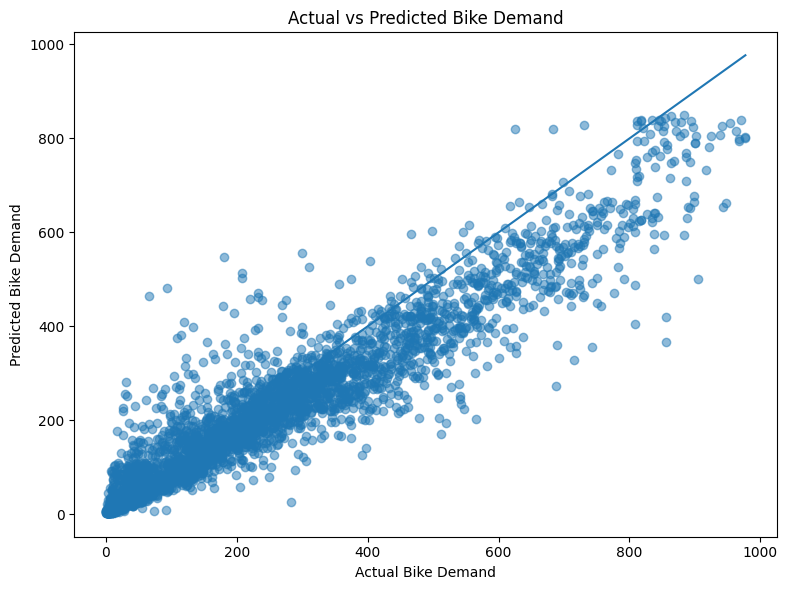

In [44]:
y_pred_rf=rf_pipeline.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_rf,alpha=0.5)

plt.xlabel("Actual Bike Demand")
plt.ylabel("Predicted Bike Demand")
plt.title("Actual vs Predicted Bike Demand")

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
)

plt.tight_layout()

plt.savefig("images/actual_predicted_bike_demand.png")




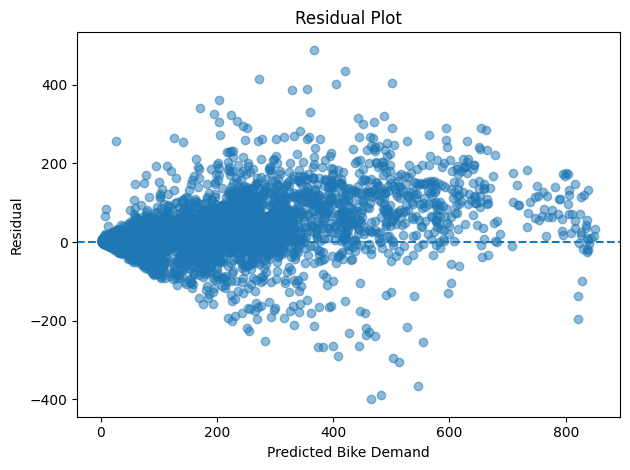

In [46]:
residual=y_test-y_pred_rf

plt.scatter(y_pred_rf,residual,alpha=0.5)

plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted Bike Demand")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.tight_layout()

plt.savefig("images/residual_plot.png")

In [47]:
rf_model=rf_pipeline.named_steps["model"]

feature_names=rf_pipeline.named_steps["ct"].get_feature_names_out()

In [49]:
importance=rf_model.feature_importances_

In [50]:
feature_importance=pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

In [52]:
feature_importance=feature_importance.sort_values(
    by="Importance",ascending=False
)

In [54]:
feature_importance.head(10)

,Feature,Importance
58,num__atemp,0.190613
35,cat__hr_17,0.091469
36,cat__hr_18,0.080080
59,num__hum,0.074908
26,cat__hr_8,0.056036
51,cat__workingday_0,0.045980
52,cat__workingday_1,0.045211
57,num__temp,0.041876
4,cat__yr_0,0.033302
5,cat__yr_1,0.032870


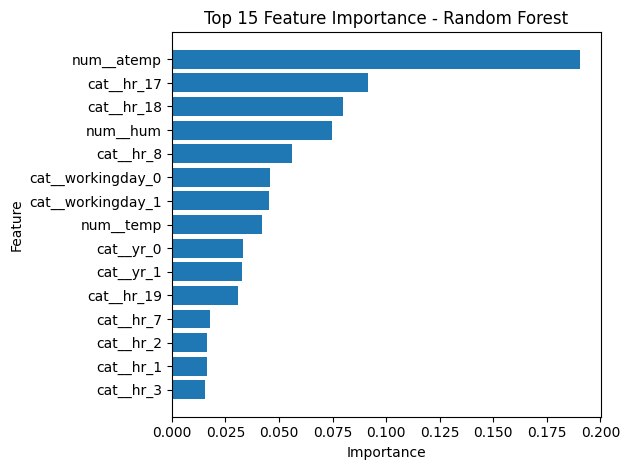

In [55]:
plt.Figure(figsize=(10,6))

top_features=feature_importance.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 15 Feature Importance - Random Forest")

plt.tight_layout()
plt.savefig("images/Top 15 Feature Importance - Random Forest.png")


In [56]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [98.7976, 54.6441],
    "MSE": [17911.9197, 6726.3550],
    "RMSE": [133.8354, 82.0144],
    "R2": [0.6315, 0.8616]
})

comparison

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,98.7976,17911.9197,133.8354,0.6315
1,Random Forest,54.6441,6726.3550,82.0144,0.8616


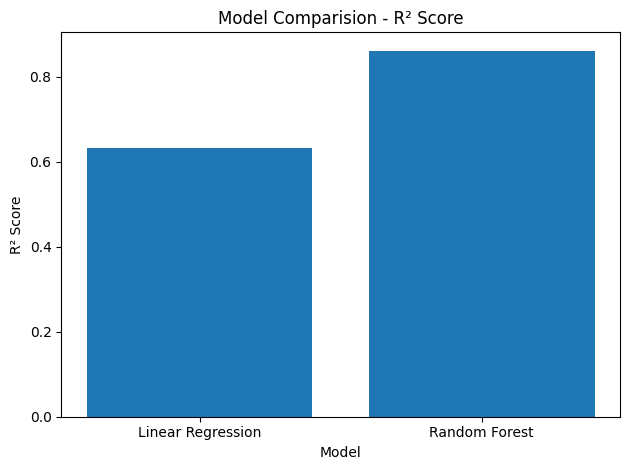

In [57]:
plt.bar(
    comparison["Model"],
    comparison["R2"]
)
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.title("Model Comparision - R² Score")

plt.tight_layout()
plt.savefig("images/model_comparision_r2_score.png")

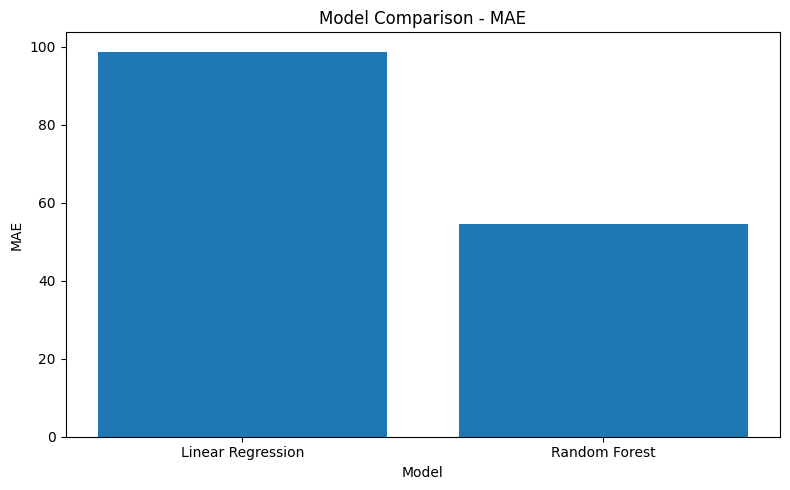

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["MAE"]
)

plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Model Comparison - MAE")

plt.savefig("images/model_comparision.png")
plt.tight_layout()
plt.show()

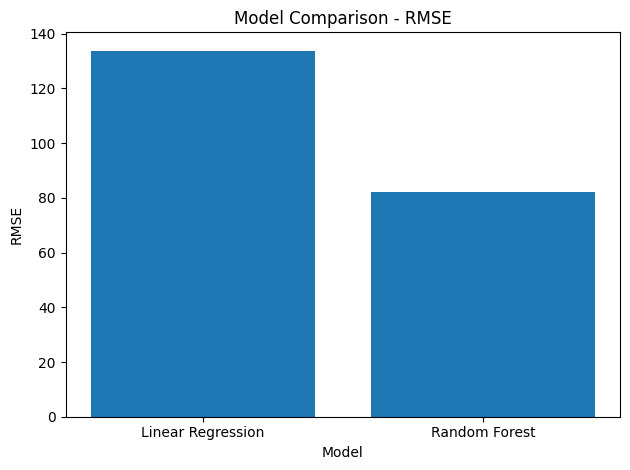

In [59]:
plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Model Comparison - RMSE")

plt.savefig("images/model_comparision_rmse.png")

plt.tight_layout()
plt.show()

In [60]:
import joblib

joblib.dump(rf_pipeline,"bike_demand_model.pkl")


['bike_demand_model.pkl']